In [1]:
import datetime
import glob
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from scipy import interpolate

import cartopy.crs as ccrs
import cartopy.feature

import parcels

import load_copernics_fieldset
from kernels import WindageRK2, Stranding, LoggerheadParticle, StokesDriftRK2, UnbeachingBySampling

/var/folders/1n/500ln6w97859_nqq86vwpl000000gr/T/ipykernel_8265/3455303736.py:15: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
df_in = pd.read_excel("stranding_locations.xlsx")
df_in


,ID,Code,Datum,Locatie,Conditie,CCL (cm),Gewicht (g)
0,CC13,1,2023-12-22,"52.00680, 4.13610",levend,20.5,1088.0
1,CC14,2,2023-12-23,"51.47140, 3.51834",levend,21.5,1400.0
2,CC15,3,2023-12-24,"52.55739, 4.60540",gestorven in opvang,20.0,1892.0
3,CC16,4,2023-12-25,"51.43989, 3.57221",gestorven in opvang,25.5,2400.0
4,CC17,5,2024-01-07,"51.83544, 3.92646",dood gevonden,NaN,1500.0
5,CC18,6,2024-01-24,"53.18004, 4.84821",gestorven in opvang,20.0,1300.0
6,CC19,7,2024-01-25,"53.13600, 4.79380",gestorven in opvang,21.0,1015.0
7,CC20,8,2024-02-05,"53.00148, 4.71497",dood gevonden,NaN,1400.0
8,CC21,9,2024-02-06,"52.84408, 4.69293",gestorven in opvang,NaN,2135.0
9,CC22,10,2024-02-08,"53.27664, 4.97249",dood gevonden,NaN,2000.0


In [3]:
offsets = {  # TODO check if still needed with UnbeachingBySampling kernel
    "CC26": (0.02, 0),
    "CC32": (0, -0.02),
    "CC23": (0.015, 0),
    "CC33": (0.01, 0),
    "CC31": (0, -0.02),
}

In [4]:
N = 10

def run_sim(beach_date, beach_lat, beach_lon, beach_id):
    fieldset = load_copernics_fieldset.create_fieldset(startdate=beach_date-datetime.timedelta(days=14), enddate=beach_date)

    # Windage coefficient [fraction]
    fieldset.wind_coeff = 0.01

    lons = beach_lon + np.random.uniform(-0.01, 0.01, size=N)
    lats = beach_lat + np.random.uniform(-0.01, 0.01, size=N)

    pfile = parcels.ParticleFile(
        f"Loggerhead_Simulation_{beach_id}.parquet",
        outputdt=np.timedelta64(1, 'h'),
        mode="w",
    )
    # fieldset.output_file = pfile  # for writing stranded particles

    pset = parcels.ParticleSet(
        fieldset=fieldset,
        pclass=LoggerheadParticle,
        lon=lons,
        lat=lats,
        time=np.datetime64(beach_date),
    )

    kernels = [
        # Stranding,
        parcels.kernels.AdvectionRK2,
        # WindageRK2,
        # StokesDriftRK2,
        UnbeachingBySampling,
    ]

    pset.execute(
        kernels=kernels,
        runtime=np.timedelta64(14, 'D'),
        dt=-np.timedelta64(10, 'm'),
        output_file=pfile,
    )
    gc.collect()

for index, row in df_in.iterrows():
    location = row["Locatie"]
    beach_id = row["ID"]
    beach_date = row["Datum"]
    if beach_date < datetime.datetime(2024, 4, 1):
        print(f"Invalid date for location {beach_id}: {beach_date}")
        continue
    if pd.isna(location):
        print(f"Invalid location for location {beach_id}: {location}")
        continue
    offset = (0, 0) if beach_id not in offsets.keys() else offsets[beach_id]
    beach_lat = float(location.split(",")[0].strip()) + offset[0]
    beach_lon = float(location.split(",")[1].strip()) + offset[1]
    print(f"Stranding location {beach_id}: Latitude: {beach_lat}, Longitude: {beach_lon} on {beach_date}")

    run_sim(beach_date, beach_lat, beach_lon, beach_id)
    break


Invalid date for location CC13: 2023-12-22 00:00:00
Invalid date for location CC14: 2023-12-23 00:00:00
Invalid date for location CC15: 2023-12-24 00:00:00
Invalid date for location CC16: 2023-12-25 00:00:00
Invalid date for location CC17: 2024-01-07 00:00:00
Invalid date for location CC18: 2024-01-24 00:00:00
Invalid date for location CC19: 2024-01-25 00:00:00
Invalid date for location CC20: 2024-02-05 00:00:00
Invalid date for location CC21: 2024-02-06 00:00:00
Invalid date for location CC22: 2024-02-08 00:00:00
Stranding location CC23: Latitude: 53.42057, Longitude: 6.07804 on 2024-04-24 00:00:00
INFO: Output files are stored in Loggerhead_Simulation_CC23.parquet
Integration time: 2024-04-10T01:00:00 100%|██████████| [00:07<00:00, 165734.02it/s]


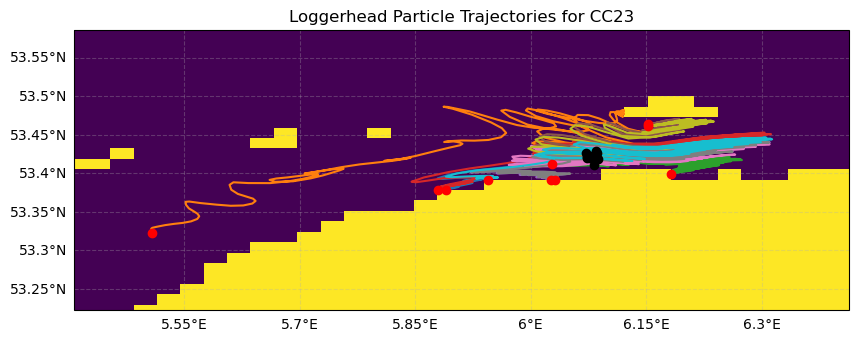

In [5]:
files = sorted(glob.glob("Loggerhead_Simulation_C*.parquet"))

beach_date = datetime.datetime(2024, 4, 24)
fieldset = load_copernics_fieldset.create_fieldset(startdate=beach_date - datetime.timedelta(days=14), enddate=beach_date)
land_mask_condition = (fieldset.U.data.isel(time=0, depth=0) == 0) & \
                      (fieldset.V.data.isel(time=0, depth=0) == 0)
landmask = np.ma.masked_where(land_mask_condition, land_mask_condition)

lon, lat = fieldset.U.grid.lon, fieldset.U.grid.lat
lon_centers = lon[1:] - np.diff(lon) / 2
lat_centers = lat[1:] - np.diff(lat) / 2
x, y = np.meshgrid(lon_centers, lat_centers)

fl = interpolate.RectBivariateSpline(lat, lon, landmask.mask, kx=1, ky=1)
lmask = (fl(y[:, 0], x[0, :]) > 0.95).astype(int)

for file in files[:1]:
    df = parcels.read_particlefile(file)

    fig = plt.figure(figsize = (10, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_facecolor('aliceblue')
    ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

    ax.pcolormesh(x, y, lmask)

    for traj in df.partition_by("particle_id", maintain_order=True):
        ax.plot(traj["lon"], traj["lat"], "-", zorder=3)
        ax.plot(traj["lon"][0], traj["lat"][0], "ko", zorder=4)
        ax.plot(traj["lon"][-1], traj["lat"][-1], "ro", zorder=4)

    ax.set_xlim([df["lon"].min() - 0.1, df["lon"].max() + 0.1])
    ax.set_ylim([df["lat"].min() - 0.1, df["lat"].max() + 0.1])
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Loggerhead Particle Trajectories for ' + file.split("_")[-1].split(".")[0])
    plt.show()
